# Laptop Price Analysis: Decoding the Indian Laptop Market
---

### Opening Question
**What drives laptop prices in India? How do brand, specifications (processor, RAM, storage, GPU), and display characteristics influence pricing? Are premium brands always more expensive, or is there a sweet spot where high specs meet reasonable prices?**

### Objective
To uncover patterns in the Indian laptop market by analysing the relationships between laptop characteristics (brand, processor, RAM, storage, GPU, display size) and pricing. Rather than making assumptions about what makes a "valuable" laptop, I'll examine actual correlations between specifications and price to identify the factors that genuinely drive costs.

### Dataset Overview
- **Sample Size**: 930+ unique laptop listings in India
- **Variables**: brand, name, price (in INR), spec_rating, processor, CPU (cores/threads), Ram (GB), Ram_type, ROM (GB), ROM_type, GPU, display_size (inches), resolution_width, resolution_height, OS, warranty (years)
- **Analysis Approach**: Exploratory Data Analysis [EDA], focusing on price distribution, brand positioning, specification impact, and market segmentation through visualisations and statistical summaries.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# set visualisation style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

In [3]:
# colour scheme for consistency
primary = "#d59de3"
secondary = "#345882"
success = "#2ca02c"
danger = "#d62728"
warning = "#ff9896"

# gradient for distributions
gradient = ["#d59de3", "#c598dd", "#b592d7", "#a48cd1", "#9386ca", "#8180c2", "#6f7bbb", "#5f74b1", "#526da6", "#46679b", "#3d5f8e", "#345882"]

### 1. What does the dataset look like at first glance?

Let me start with the basics. Load the data, take a look at structure, size, and get an initial sense of what we're working with.

In [4]:
# load the dataset
df = pd.read_csv("laptopprice.csv")

# drop the unnamed index column if it exists
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names and types:\n{df.dtypes}")

Dataset shape: (893, 17)

Column names and types:
Unnamed: 0.1           int64
brand                    str
name                     str
price                  int64
spec_rating          float64
processor                str
CPU                      str
Ram                      str
Ram_type                 str
ROM                      str
ROM_type                 str
GPU                      str
display_size         float64
resolution_width     float64
resolution_height    float64
OS                       str
warranty               int64
dtype: object


In [5]:
# first few rows
print("Sample listings:")
df.head()

Sample listings:


,Unnamed: 0.1,brand,name,price,spec_rating,processor,CPU,Ram,Ram_type,ROM,ROM_type,GPU,display_size,resolution_width,resolution_height,OS,warranty
0,0,HP,Victus 15-fb0157AX Gaming Laptop,49900,73.000000,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads",8GB,DDR4,512GB,SSD,4GB AMD Radeon RX 6500M,15.6,1920.0,1080.0,Windows 11 OS,1
1,1,HP,15s-fq5007TU Laptop,39900,60.000000,12th Gen Intel Core i3 1215U,"Hexa Core (2P + 4E), 8 Threads",8GB,DDR4,512GB,SSD,Intel UHD Graphics,15.6,1920.0,1080.0,Windows 11 OS,1
2,2,Acer,One 14 Z8-415 Laptop,26990,69.323529,11th Gen Intel Core i3 1115G4,"Dual Core, 4 Threads",8GB,DDR4,512GB,SSD,Intel Iris Xe Graphics,14.0,1920.0,1080.0,Windows 11 OS,1
3,3,Lenovo,Yoga Slim 6 14IAP8 82WU0095IN Laptop,59729,66.000000,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads",16GB,LPDDR5,512GB,SSD,Intel Integrated Iris Xe,14.0,2240.0,1400.0,Windows 11 OS,1
4,4,Apple,MacBook Air 2020 MGND3HN Laptop,69990,69.323529,Apple M1,Octa Core (4P + 4E),8GB,DDR4,256GB,SSD,Apple M1 Integrated Graphics,13.3,2560.0,1600.0,Mac OS,1


In [6]:
# basic statistics
print("\nNumeric summary:")
df.describe()


Numeric summary:


,Unnamed: 0.1,price,spec_rating,display_size,resolution_width,resolution_height,warranty
count,893.000000,893.000000,893.000000,893.000000,893.000000,893.000000,893.000000
mean,467.135498,79907.409854,69.379026,15.173751,2035.393057,1218.324748,1.079507
std,270.209769,60880.043823,5.541555,0.939095,426.076009,326.756883,0.326956
min,0.000000,9999.000000,60.000000,11.600000,1080.000000,768.000000,0.000000
25%,235.000000,44500.000000,66.000000,14.000000,1920.000000,1080.000000,1.000000
50%,467.000000,61990.000000,69.323529,15.600000,1920.000000,1080.000000,1.000000
75%,702.000000,90990.000000,71.000000,15.600000,1920.000000,1200.000000,1.000000
max,930.000000,450039.000000,89.000000,18.000000,3840.000000,3456.000000,3.000000


In [7]:
# data quality check
print("\nMissing values:")
missing_data = df.isnull().sum()
missing_percent = (missing_data / (len(df)-1)) * 100
missing_df = pd.DataFrame({"Missing": missing_data, "Percent": missing_percent})
print(missing_df[missing_df["Missing"] > 0])

print(f"\nDuplicate listings: {df.duplicated().sum()}")


Missing values:
Empty DataFrame
Columns: [Missing, Percent]
Index: []

Duplicate listings: 0


### 2. Understanding Brand and OS Distribution

First question: which brands dominate the market? And what operating systems are people using?

Brand distribution:
brand
HP           186
Lenovo       169
Asus         157
Dell         107
Acer          84
MSI           65
Samsung       28
Apple         16
Infinix       15
LG             9
Xiaomi         8
Gigabyte       8
Fujitsu        6
Ultimus        4
Zebronics      4
Wings          3
Chuwi          3
Realme         3
Tecno          3
Honor          2
Huawei         2
Microsoft      2
AXL            2
Primebook      1
iBall          1
Avita          1
Walker         1
Vaio           1
Ninkear        1
Razer          1
Name: count, dtype: int64

Percentages:
brand
HP           20.83
Lenovo       18.92
Asus         17.58
Dell         11.98
Acer          9.41
MSI           7.28
Samsung       3.14
Apple         1.79
Infinix       1.68
LG            1.01
Xiaomi        0.90
Gigabyte      0.90
Fujitsu       0.67
Ultimus       0.45
Zebronics     0.45
Wings         0.34
Chuwi         0.34
Realme        0.34
Tecno         0.34
Honor         0.22
Huawei        0.22
Microsoft     0.22


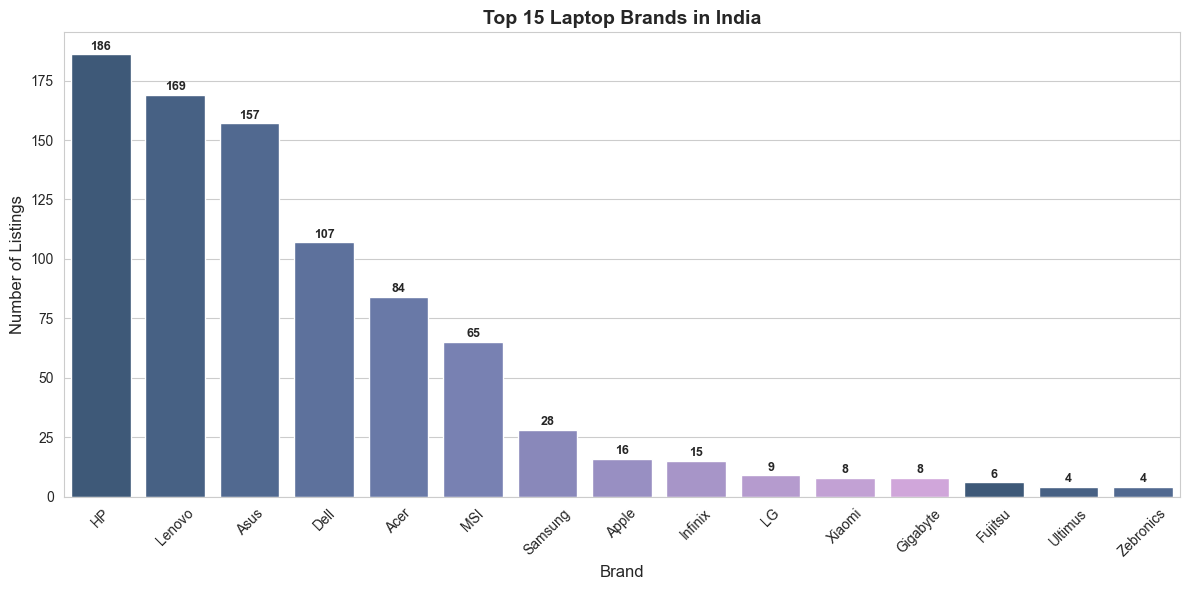

In [8]:
# brand distribution
brand_counts = df["brand"].value_counts()
print("Brand distribution:")
print(brand_counts)
print(f"\nPercentages:")
print((brand_counts / len(df) * 100).round(2))

# bar chart - top 15 brands
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=brand_counts.head(15).index, y=brand_counts.head(15).values, palette=gradient[::-1], ax=ax)
ax.set_title('Top 15 Laptop Brands in India', fontsize=14, fontweight='bold')
ax.set_xlabel('Brand', fontsize=12)
ax.set_ylabel('Number of Listings', fontsize=12)
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(brand_counts.head(15).values):
    ax.text(i, v + 2, f'{v}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()


Operating System distribution:
OS
Windows 11 OS         782
Windows 10 OS          28
DOS OS                 18
Windows 11  OS         15
Mac OS                 12
Windows 10  OS         10
Chrome OS              10
Windows OS              9
Ubuntu OS               2
DOS 3.0 OS              2
Mac 10.15.3\t OS        2
Android 11 OS           1
Mac Catalina OS         1
Mac High Sierra OS      1
Name: count, dtype: int64

Percentages:
OS
Windows 11 OS         87.57
Windows 10 OS          3.14
DOS OS                 2.02
Windows 11  OS         1.68
Mac OS                 1.34
Windows 10  OS         1.12
Chrome OS              1.12
Windows OS             1.01
Ubuntu OS              0.22
DOS 3.0 OS             0.22
Mac 10.15.3\t OS       0.22
Android 11 OS          0.11
Mac Catalina OS        0.11
Mac High Sierra OS     0.11
Name: count, dtype: float64


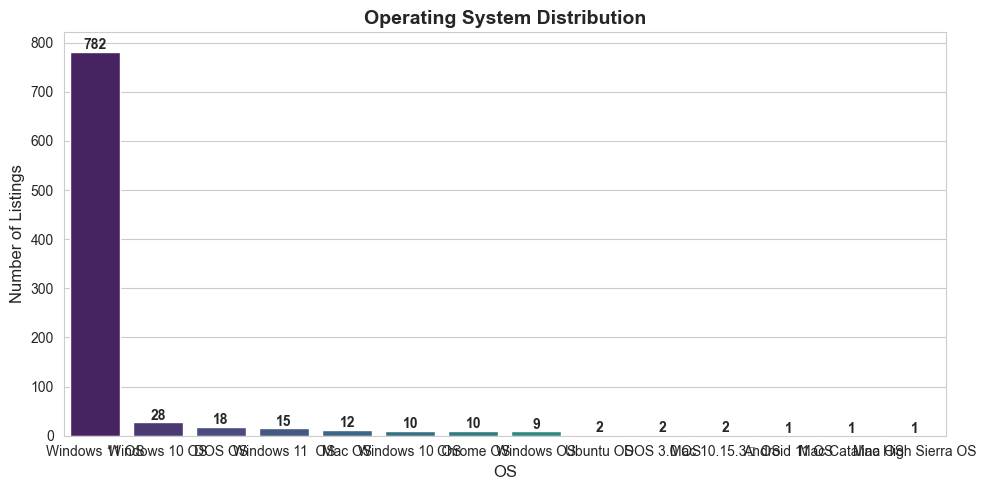

In [9]:
# OS distribution
print("\nOperating System distribution:")
os_counts = df["OS"].value_counts()
print(os_counts)
print(f"\nPercentages:")
print((os_counts / len(df) * 100).round(2))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=os_counts.index, y=os_counts.values, palette='viridis', ax=ax)
ax.set_title('Operating System Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('OS', fontsize=12)
ax.set_ylabel('Number of Listings', fontsize=12)
for i, v in enumerate(os_counts.values):
    ax.text(i, v + 5, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

### 3. Pricing Analysis: What Are People Paying?

Price is where things get interesting. What's the distribution like? Are there outliers? Do prices vary wildly by brand and specifications?

Price statistics (in INR):
Mean: ₹79,907.41
Median: ₹61,990.00
Min: ₹9,999.00
Max: ₹450,039.00
Std Dev: ₹60,880.04


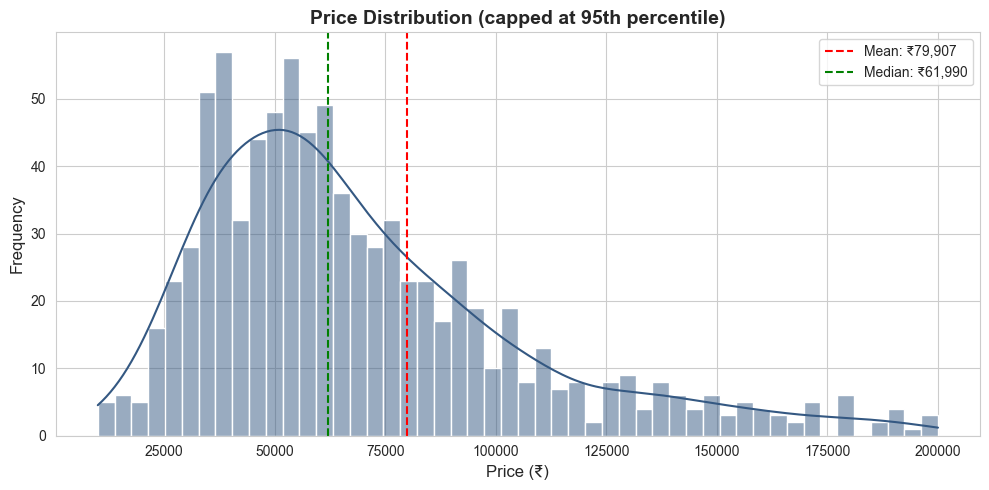

In [10]:
# price statistics
print("Price statistics (in INR):")
print(f"Mean: ₹{df['price'].mean():,.2f}")
print(f"Median: ₹{df['price'].median():,.2f}")
print(f"Min: ₹{df['price'].min():,.2f}")
print(f"Max: ₹{df['price'].max():,.2f}")
print(f"Std Dev: ₹{df['price'].std():,.2f}")

# histogram (capped at 95th percentile for visibility)
cap = df['price'].quantile(0.95)
filtered_price = df[df['price'] <= cap]['price']
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(filtered_price, bins=50, kde=True, color=secondary, ax=ax)
ax.set_title('Price Distribution (capped at 95th percentile)', fontsize=14, fontweight='bold')
ax.set_xlabel('Price (₹)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.axvline(df['price'].mean(), color='red', linestyle='--', label=f"Mean: ₹{df['price'].mean():,.0f}")
ax.axvline(df['price'].median(), color='green', linestyle='--', label=f"Median: ₹{df['price'].median():,.0f}")
ax.legend()
plt.tight_layout()
plt.show()


Price by brand (top 15):
           Count       Mean    Median   Std Dev     Min     Max
brand                                                          
Razer          1  199990.00  199990.0       NaN  199990  199990
Apple         16  174230.88  172445.0  74456.33   69990  309490
Gigabyte       8  133279.12  136850.0  37285.87   74990  189999
LG             9  128618.44  127000.0  38773.19   78299  205000
Samsung       28  117512.14  106490.0  56200.15   49990  281990
MSI           65  100849.63   79990.0  82638.00   33990  420000
Dell         107   91150.93   67990.0  71746.00   31490  450039
Fujitsu        6   81656.67   79990.0  14719.60   64990  104990
HP           186   80872.47   59490.0  64262.96   15990  415000
Ninkear        1   79999.00   79999.0       NaN   79999   79999
Asus         157   75774.19   65990.0  51192.43   10990  429990
Lenovo       169   70060.95   57799.0  49888.30   18990  399999
Microsoft      2   60440.00   60440.0     70.71   60390   60490
Acer          

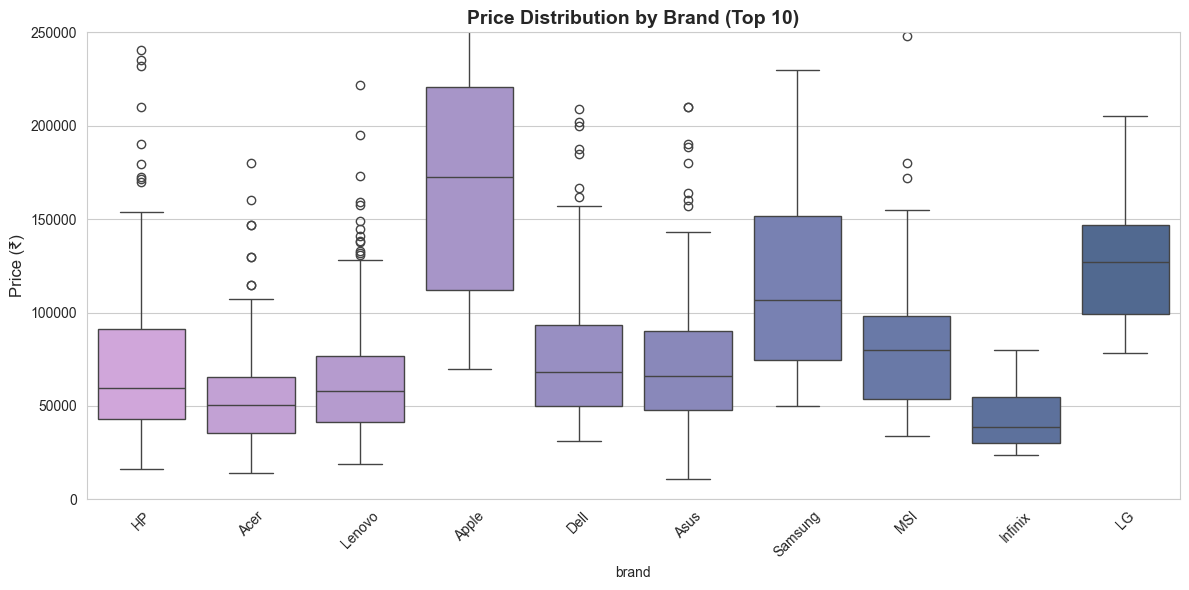

In [11]:
# price by brand
print("\nPrice by brand (top 15):")
brand_price = df.groupby("brand")["price"].agg(["count", "mean", "median", "std", "min", "max"])
brand_price.columns = ["Count", "Mean", "Median", "Std Dev", "Min", "Max"]
brand_price_sorted = brand_price.sort_values("Mean", ascending=False)
print(brand_price_sorted.head(15).round(2))

# boxplot - top 10 brands by count
top_brands = df['brand'].value_counts().head(10).index
df_top_brands = df[df['brand'].isin(top_brands)]
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_top_brands, x='brand', y='price', palette=gradient, ax=ax)
ax.set_title('Price Distribution by Brand (Top 10)', fontsize=14, fontweight='bold')
ax.set_ylabel('Price (₹)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(0, 250000)  # zoom in for readability
plt.tight_layout()
plt.show()

In [12]:
# detect outliers using IQR
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["price"] < lower_bound) | (df["price"] > upper_bound)]
print(f"Price outliers detected: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
print(f"Outlier range: ₹{lower_bound:,.2f} to ₹{upper_bound:,.2f}")
print(f"\nActual extreme values: ₹{df['price'].min():,.2f} to ₹{df['price'].max():,.2f}")

Price outliers detected: 71 (7.95%)
Outlier range: ₹-25,235.00 to ₹160,725.00

Actual extreme values: ₹9,999.00 to ₹450,039.00


### 4. RAM Analysis: How Much Memory?

RAM is one of the most important specs. What's the distribution like? Who's offering more RAM, and does it significantly affect price?

RAM distribution:
Mean: 13.3 GB
Median: 16.0 GB
Min: 2 GB
Max: 64 GB


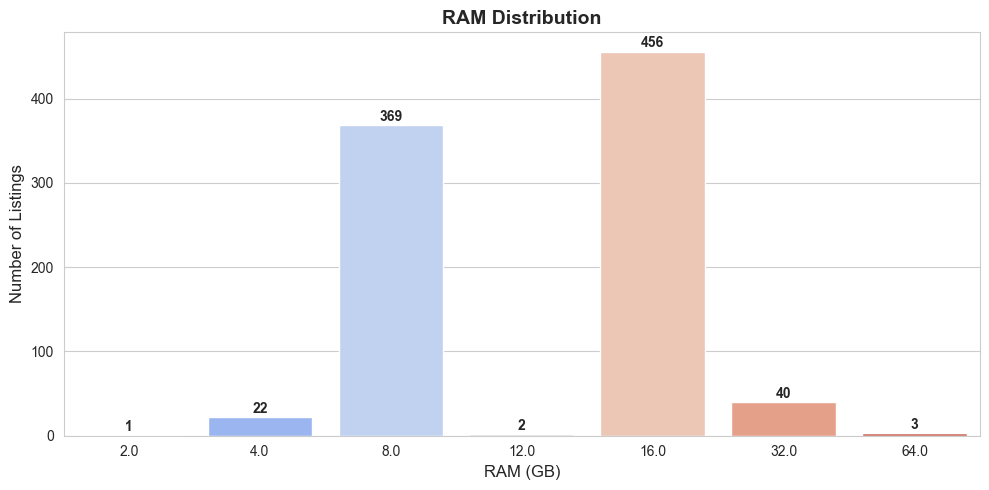


RAM type distribution:
Ram_type
DDR4       499
DDR5       166
LPDDR5     145
LPDDR4X     41
LPDDR4      14
LPDDR4x     13
Unified      7
DDR3         3
LPDDR5X      2
DDR4-        1
LPDDR5x      1
DDR          1
Name: count, dtype: int64

Percentages:
Ram_type
DDR4       55.88
DDR5       18.59
LPDDR5     16.24
LPDDR4X     4.59
LPDDR4      1.57
LPDDR4x     1.46
Unified     0.78
DDR3        0.34
LPDDR5X     0.22
DDR4-       0.11
LPDDR5x     0.11
DDR         0.11
Name: count, dtype: float64

Price by RAM:
      Mean Price  Median Price  Count
Ram                                  
2.0      9999.00        9999.0      1
4.0     19780.41       19920.0     22
8.0     49270.36       44990.0    369
12.0    42990.00       42990.0      2
16.0    91741.90       79990.0    456
32.0   238026.80      253994.5     40
64.0   430009.67      420000.0      3


In [13]:
# RAM statistics
df['Ram'] = df['Ram'].astype(str).str.extract('(\d+)').astype(float)
print("RAM distribution:")
print(f"Mean: {df['Ram'].mean():.1f} GB")
print(f"Median: {df['Ram'].median():.1f} GB")
print(f"Min: {df['Ram'].min():.0f} GB")
print(f"Max: {df['Ram'].max():.0f} GB")

# bar chart
ram_counts = df['Ram'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=ram_counts.index, y=ram_counts.values, palette='coolwarm', ax=ax)
ax.set_title('RAM Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('RAM (GB)', fontsize=12)
ax.set_ylabel('Number of Listings', fontsize=12)
for i, v in enumerate(ram_counts.values):
    ax.text(i, v + 5, f'{v}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# RAM type distribution
print("\nRAM type distribution:")
ram_type_counts = df["Ram_type"].value_counts()
print(ram_type_counts)
print(f"\nPercentages:")
print((ram_type_counts / len(df) * 100).round(2))

# price by RAM
ram_price = df.groupby("Ram")["price"].agg(["mean", "median", "count"]).round(2)
ram_price.columns = ["Mean Price", "Median Price", "Count"]
print("\nPrice by RAM:")
print(ram_price)

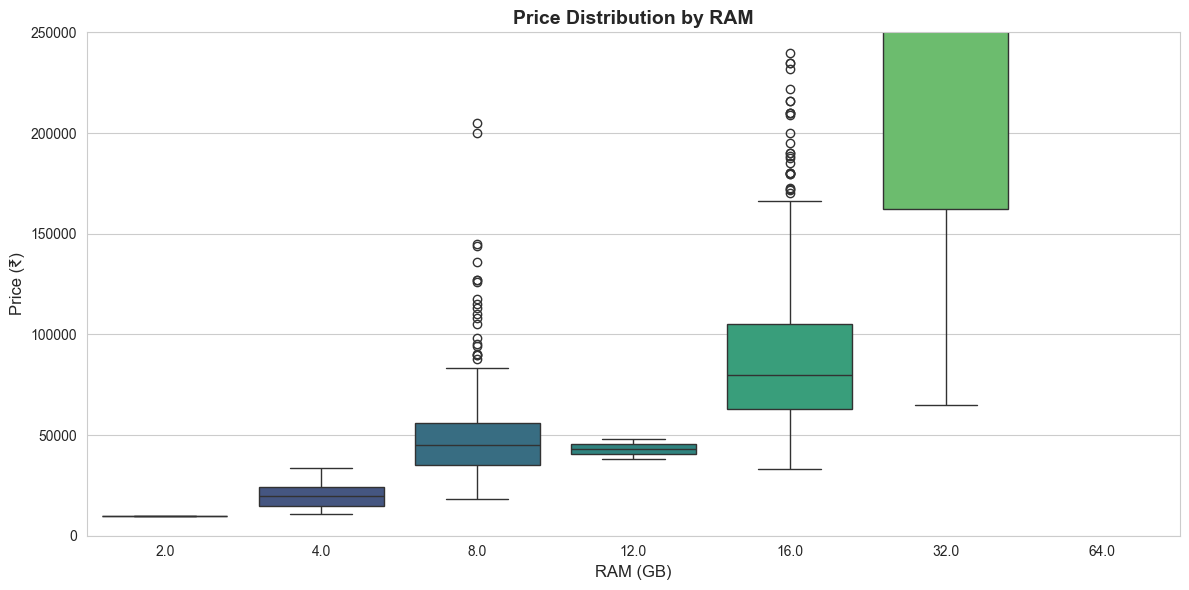

In [14]:
# boxplot of price by RAM
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df, x='Ram', y='price', palette='viridis', ax=ax)
ax.set_title('Price Distribution by RAM', fontsize=14, fontweight='bold')
ax.set_xlabel('RAM (GB)', fontsize=12)
ax.set_ylabel('Price (₹)', fontsize=12)
ax.set_ylim(0, 250000)
plt.tight_layout()
plt.show()

### 5. Storage Analysis: SSD vs HDD

Storage type and size matter. Are SSDs dominating? How much storage do people usually get?

ROM type distribution:
ROM_type
SSD          872
Hard-Disk     21
Name: count, dtype: int64

Percentages:
ROM_type
SSD          97.65
Hard-Disk     2.35
Name: count, dtype: float64

ROM size distribution:
ROM
128GB     12
1TB      188
256GB     42
2TB       10
32GB       2
512GB    634
64GB       5
Name: count, dtype: int64


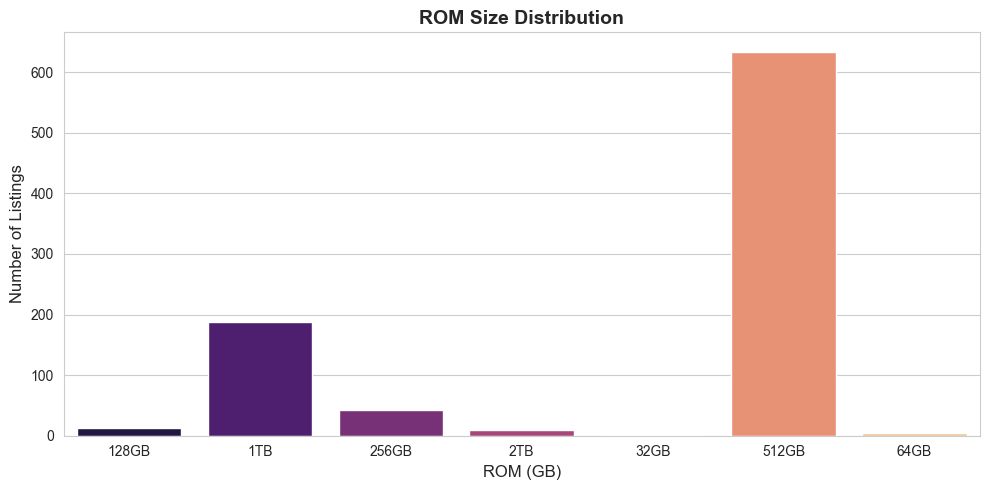


Price by ROM type:
           Mean Price  Median Price  Count
ROM_type                                  
Hard-Disk    38467.95       37990.0     21
SSD          80905.38       62990.0    872


In [15]:
# ROM type distribution
print("ROM type distribution:")
rom_type_counts = df["ROM_type"].value_counts()
print(rom_type_counts)
print(f"\nPercentages:")
print((rom_type_counts / len(df) * 100).round(2))

# ROM size distribution
rom_counts = df['ROM'].value_counts().sort_index()
print("\nROM size distribution:")
print(rom_counts)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=rom_counts.index, y=rom_counts.values, palette='magma', ax=ax)
ax.set_title('ROM Size Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('ROM (GB)', fontsize=12)
ax.set_ylabel('Number of Listings', fontsize=12)
plt.tight_layout()
plt.show()

# price by ROM type
rom_type_price = df.groupby("ROM_type")["price"].agg(["mean", "median", "count"]).round(2)
rom_type_price.columns = ["Mean Price", "Median Price", "Count"]
print("\nPrice by ROM type:")
print(rom_type_price)

### 6. Processor Analysis: The Brains of the Operation

Which processors are most common? Intel vs AMD, and how does that affect pricing?

Processor family distribution:
processor_family
Intel       609
AMD         265
Apple        12
Other         6
MediaTek      1
Name: count, dtype: int64


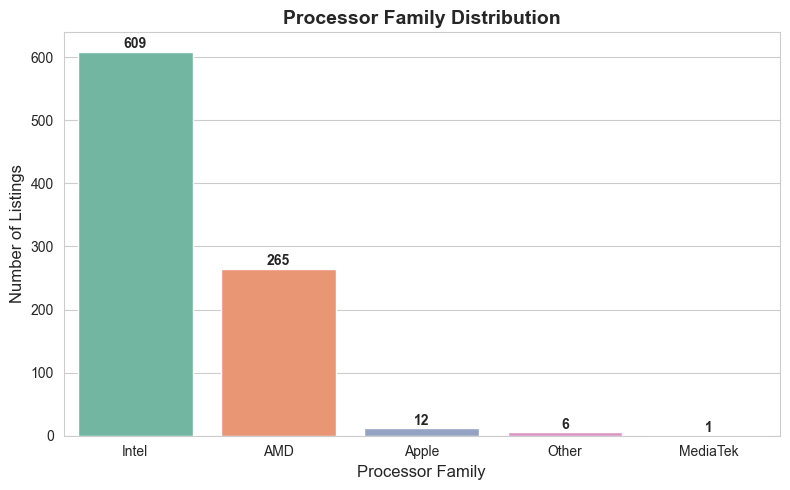

In [16]:
# processor family distribution
def extract_processor_family(processor):
    if pd.isna(processor):
        return "Unknown"
    if 'Intel' in processor:
        return 'Intel'
    elif 'AMD' in processor or 'Amd' in processor:
        return 'AMD'
    elif 'Apple' in processor:
        return 'Apple'
    elif 'MediaTek' in processor:
        return 'MediaTek'
    else:
        return 'Other'

df['processor_family'] = df['processor'].apply(extract_processor_family)
print("Processor family distribution:")
proc_family = df['processor_family'].value_counts()
print(proc_family)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=proc_family.index, y=proc_family.values, palette='Set2', ax=ax)
ax.set_title('Processor Family Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Processor Family', fontsize=12)
ax.set_ylabel('Number of Listings', fontsize=12)
for i, v in enumerate(proc_family.values):
    ax.text(i, v + 5, f'{v}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


Price by processor family:
                  Mean Price  Median Price  Count
processor_family                                 
Apple              183608.17      180492.0     12
Intel               84244.01       64990.0    609
AMD                 66232.36       55990.0    265
Other               47808.33       35490.0      6
MediaTek            10990.00       10990.0      1


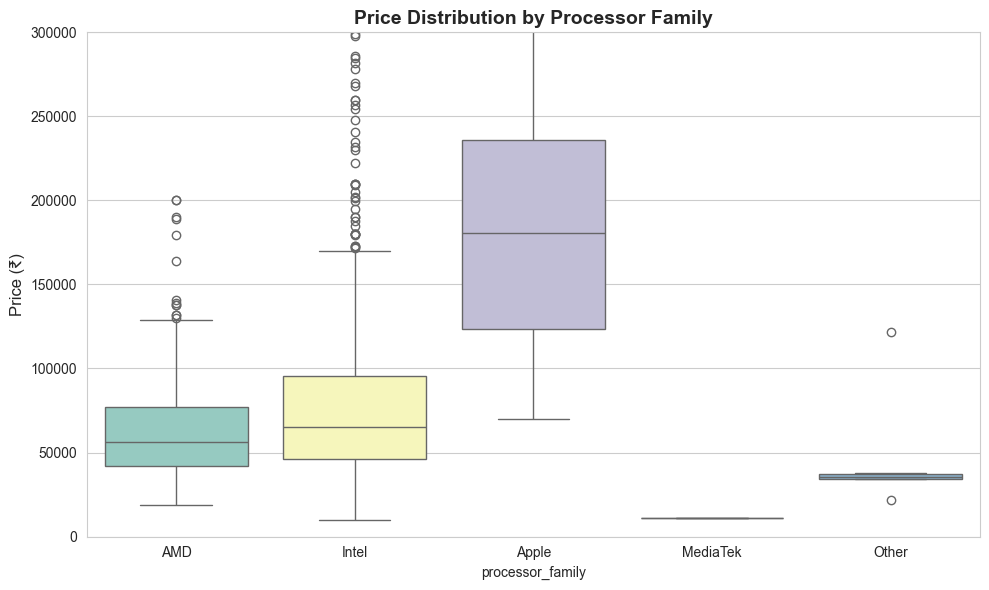

In [17]:
# price by processor family
proc_price = df.groupby("processor_family")["price"].agg(["mean", "median", "count"]).round(2)
proc_price.columns = ["Mean Price", "Median Price", "Count"]
print("\nPrice by processor family:")
print(proc_price.sort_values("Mean Price", ascending=False))

# boxplot
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='processor_family', y='price', palette='Set3', ax=ax)
ax.set_title('Price Distribution by Processor Family', fontsize=14, fontweight='bold')
ax.set_ylabel('Price (₹)', fontsize=12)
ax.set_ylim(0, 300000)
plt.tight_layout()
plt.show()

### 7. GPU Analysis: Graphics Power

Do laptops with dedicated GPUs cost significantly more? Let's find out.

GPU category distribution:
gpu_category
Intel Integrated    400
NVIDIA              306
AMD                 174
Other                11
Apple                 2
Name: count, dtype: int64

Percentages:
gpu_category
Intel Integrated    44.79
NVIDIA              34.27
AMD                 19.48
Other                1.23
Apple                0.22
Name: count, dtype: float64


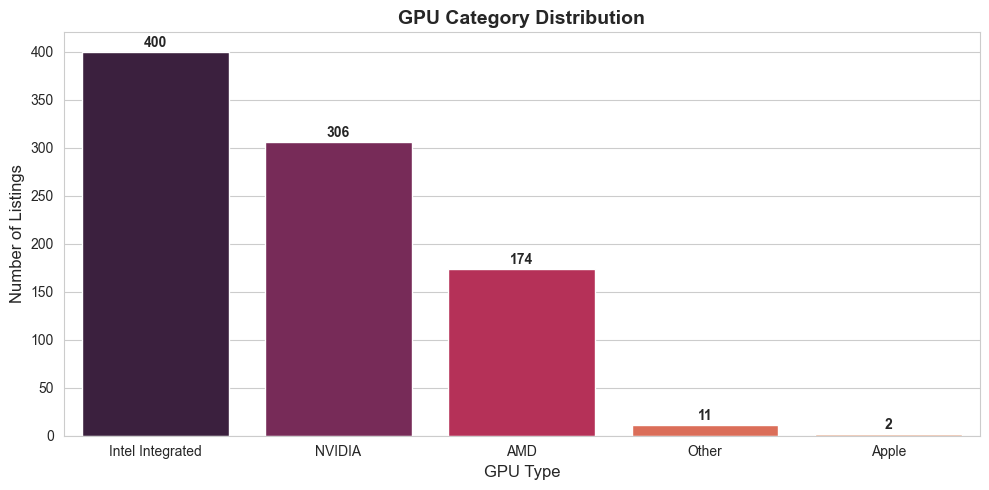

In [18]:
# categorise GPU type
def categorise_gpu(gpu):
    if pd.isna(gpu):
        return "Unknown"
    gpu_lower = str(gpu).lower()
    if 'nvidia' in gpu_lower or 'geforce' in gpu_lower or 'rtx' in gpu_lower or 'gtx' in gpu_lower:
        return 'NVIDIA'
    elif 'amd' in gpu_lower or 'radeon' in gpu_lower:
        return 'AMD'
    elif 'intel' in gpu_lower or 'iris' in gpu_lower or 'uhd' in gpu_lower:
        return 'Intel Integrated'
    elif 'apple' in gpu_lower or 'm1' in gpu_lower or 'm2' in gpu_lower:
        return 'Apple'
    else:
        return 'Other'

df['gpu_category'] = df['GPU'].apply(categorise_gpu)
print("GPU category distribution:")
gpu_cat = df['gpu_category'].value_counts()
print(gpu_cat)
print(f"\nPercentages:")
print((gpu_cat / len(df) * 100).round(2))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=gpu_cat.index, y=gpu_cat.values, palette='rocket', ax=ax)
ax.set_title('GPU Category Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('GPU Type', fontsize=12)
ax.set_ylabel('Number of Listings', fontsize=12)
for i, v in enumerate(gpu_cat.values):
    ax.text(i, v + 5, f'{v}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


Price by GPU category:
                  Mean Price  Median Price  Count
gpu_category                                     
Other              184664.36      215994.0     11
NVIDIA             115151.14       89990.0    306
Apple               91490.00       91490.0      2
Intel Integrated    62652.89       52990.0    400
AMD                 50836.91       48490.0    174


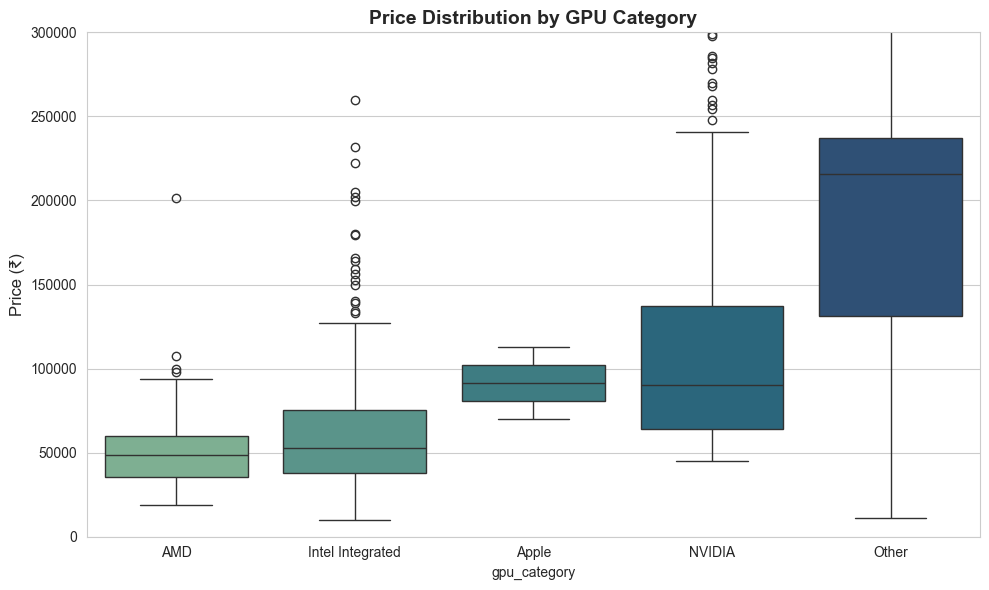

In [19]:
# price by GPU category
gpu_price = df.groupby("gpu_category")["price"].agg(["mean", "median", "count"]).round(2)
gpu_price.columns = ["Mean Price", "Median Price", "Count"]
print("\nPrice by GPU category:")
print(gpu_price.sort_values("Mean Price", ascending=False))

# boxplot
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='gpu_category', y='price', palette='crest', ax=ax)
ax.set_title('Price Distribution by GPU Category', fontsize=14, fontweight='bold')
ax.set_ylabel('Price (₹)', fontsize=12)
ax.set_ylim(0, 300000)
plt.tight_layout()
plt.show()

### 8. Display Analysis: Size and Resolution

What screen sizes are popular? Does resolution affect price?

Display size statistics:
Mean: 15.2 inches
Median: 15.6 inches
Min: 11.6 inches
Max: 18.0 inches


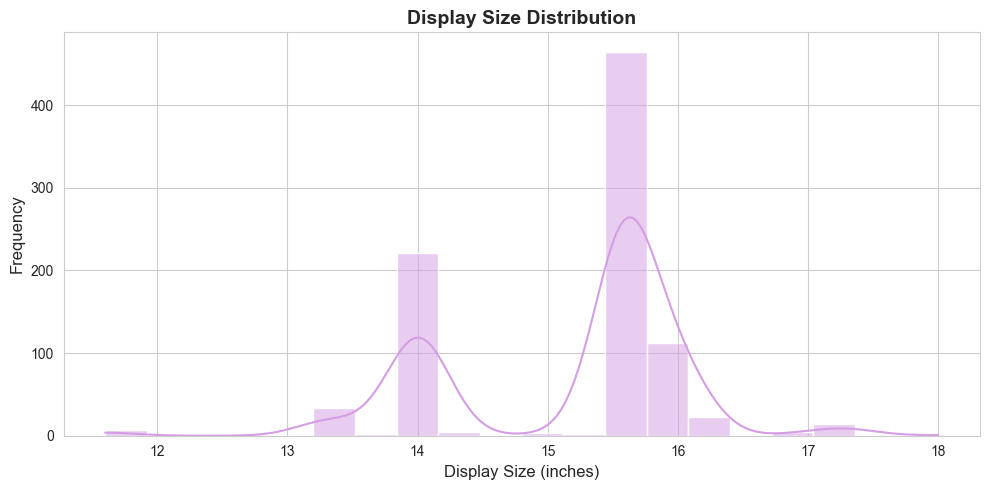

In [20]:
# display size distribution
print("Display size statistics:")
print(f"Mean: {df['display_size'].mean():.1f} inches")
print(f"Median: {df['display_size'].median():.1f} inches")
print(f"Min: {df['display_size'].min():.1f} inches")
print(f"Max: {df['display_size'].max():.1f} inches")

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['display_size'], bins=20, kde=True, color=primary, ax=ax)
ax.set_title('Display Size Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Display Size (inches)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

Resolution category distribution:
resolution_category
Full HD (1920)    688
QHD/2K (2560+)    130
HD (1366/1280)     61
4K (3840+)         14
Name: count, dtype: int64

Percentages:
resolution_category
Full HD (1920)    77.04
QHD/2K (2560+)    14.56
HD (1366/1280)     6.83
4K (3840+)         1.57
Name: count, dtype: float64


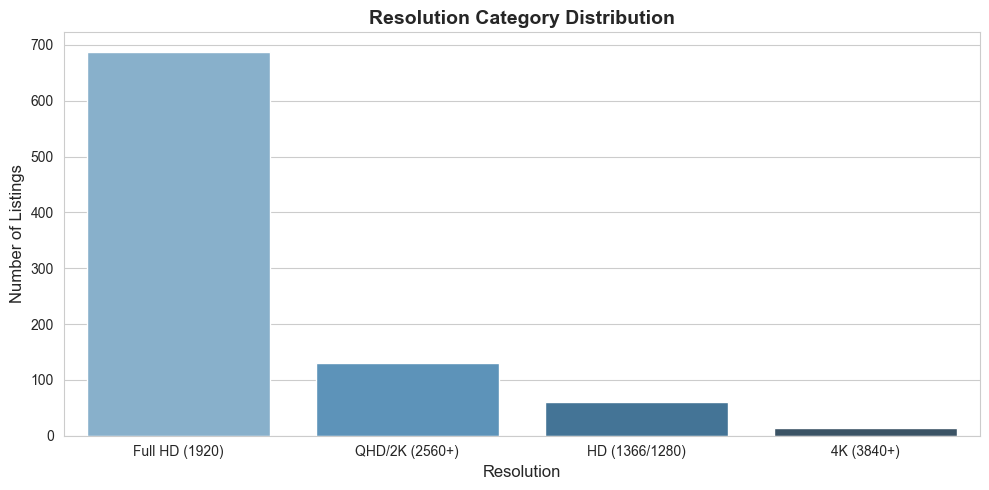


Price by resolution:
                     Mean Price  Median Price  Count
resolution_category                                 
4K (3840+)            225007.43      195994.5     14
Full HD (1920)         64880.14       57990.0    688
HD (1366/1280)         52214.72       29999.0     61
QHD/2K (2560+)        156804.45      140490.0    130


In [21]:
# create resolution categories
def categorise_resolution(width, height):
    if width == 0 or height == 0:
        return "Unknown"
    if width >= 3840:
        return "4K (3840+)"
    elif width >= 2560:
        return "QHD/2K (2560+)"
    elif width >= 1920:
        return "Full HD (1920)"
    else:
        return "HD (1366/1280)"

df['resolution_category'] = df.apply(lambda row: categorise_resolution(row['resolution_width'], row['resolution_height']), axis=1)
print("Resolution category distribution:")
res_cat = df['resolution_category'].value_counts()
print(res_cat)
print(f"\nPercentages:")
print((res_cat / len(df) * 100).round(2))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=res_cat.index, y=res_cat.values, palette='Blues_d', ax=ax)
ax.set_title('Resolution Category Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Resolution', fontsize=12)
ax.set_ylabel('Number of Listings', fontsize=12)
plt.tight_layout()
plt.show()

# price by resolution
res_price = df.groupby("resolution_category")["price"].agg(["mean", "median", "count"]).round(2)
res_price.columns = ["Mean Price", "Median Price", "Count"]
print("\nPrice by resolution:")
print(res_price)

### 9. Warranty Analysis: How Long Are They Covered?

Warranty can be a sign of quality. Does longer warranty mean higher prices?

Warranty distribution:
warranty
0      6
1    819
2     59
3      9
Name: count, dtype: int64

Percentages:
warranty
0     0.67
1    91.71
2     6.61
3     1.01
Name: count, dtype: float64


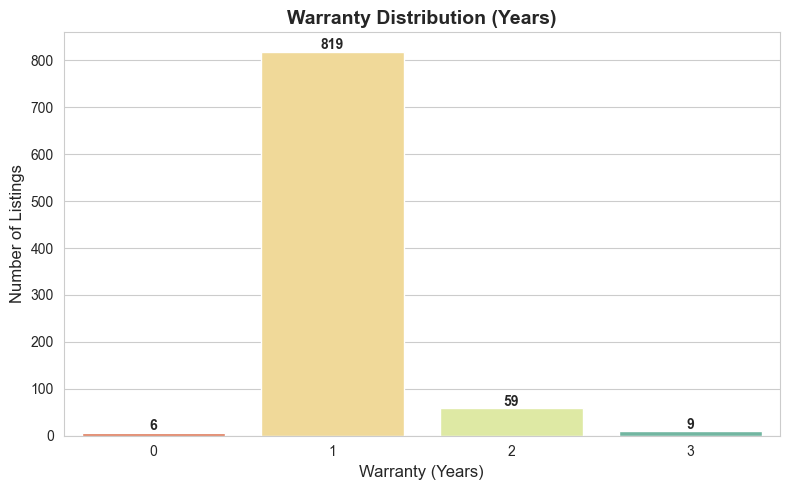


Price by warranty:
          Mean Price  Median Price  Count
warranty                                 
0          114816.00      115949.5      6
1           77151.23       59990.0    819
2          110536.29       82990.0     59
3          106658.00       90464.0      9


In [22]:
# warranty distribution
print("Warranty distribution:")
warranty_counts = df['warranty'].value_counts().sort_index()
print(warranty_counts)
print(f"\nPercentages:")
print((warranty_counts / len(df) * 100).round(2))

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=warranty_counts.index, y=warranty_counts.values, palette='Spectral', ax=ax)
ax.set_title('Warranty Distribution (Years)', fontsize=14, fontweight='bold')
ax.set_xlabel('Warranty (Years)', fontsize=12)
ax.set_ylabel('Number of Listings', fontsize=12)
for i, v in enumerate(warranty_counts.values):
    ax.text(i, v + 5, f'{v}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# price by warranty
warranty_price = df.groupby("warranty")["price"].agg(["mean", "median", "count"]).round(2)
warranty_price.columns = ["Mean Price", "Median Price", "Count"]
print("\nPrice by warranty:")
print(warranty_price)

### 10. Correlations: What Actually Drives Price?

Now for the interesting part. What factors actually correlate with higher prices? Is RAM more important than storage? Does display size matter?

In [23]:
# correlation matrix for numerical variables
df['ROM'] = df['ROM'].astype(str).str.extract('(\d+)').astype(float)
numeric_cols = ["price", "spec_rating", "Ram", "ROM", "display_size", "resolution_width", "resolution_height", "warranty"]

# check if spec_rating has missing values - fill with median
df_corr = df.copy()
df_corr['spec_rating'] = df_corr['spec_rating'].fillna(df_corr['spec_rating'].median())

correlation_matrix = df_corr[numeric_cols].corr()
print("Correlation matrix:")
correlation_matrix.round(3)

Correlation matrix:


,price,spec_rating,Ram,ROM,display_size,resolution_width,resolution_height,warranty
price,1.000,0.546,0.737,-0.481,0.234,0.586,0.605,0.117
spec_rating,0.546,1.000,0.403,-0.396,0.274,0.338,0.329,0.110
Ram,0.737,0.403,1.000,-0.363,0.188,0.468,0.427,0.137
ROM,-0.481,-0.396,-0.363,1.000,-0.075,-0.325,-0.323,-0.072
display_size,0.234,0.274,0.188,-0.075,1.000,0.125,0.030,0.041
resolution_width,0.586,0.338,0.468,-0.325,0.125,1.000,0.732,0.024
resolution_height,0.605,0.329,0.427,-0.323,0.030,0.732,1.000,-0.001
warranty,0.117,0.110,0.137,-0.072,0.041,0.024,-0.001,1.000


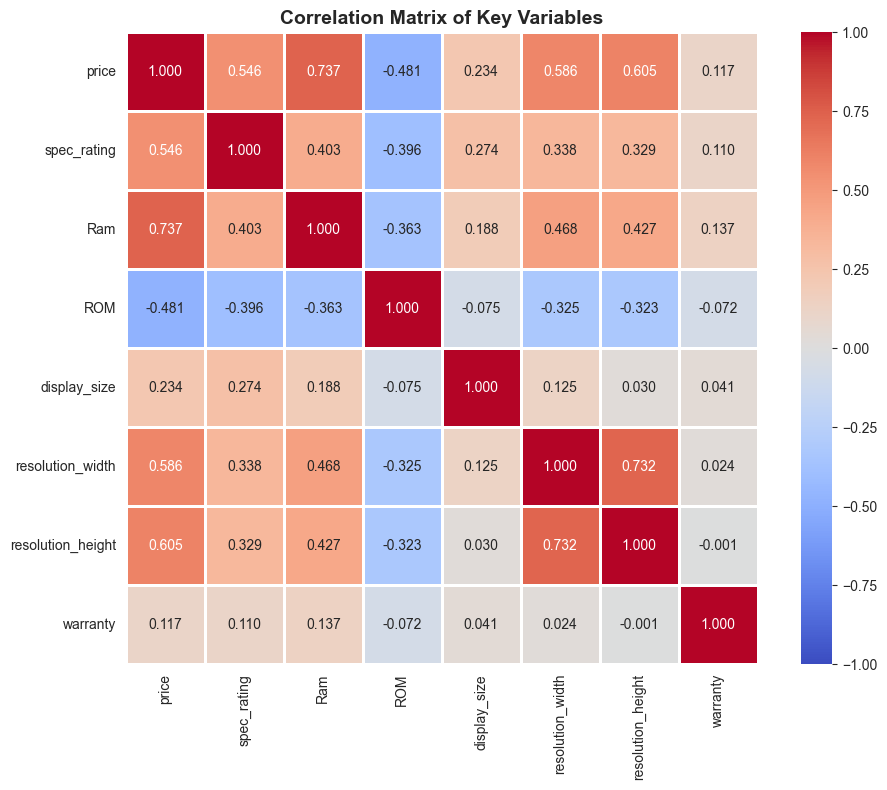

In [24]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f', center=0, square=True, linewidths=1, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix of Key Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Correlation between RAM and price: 0.737


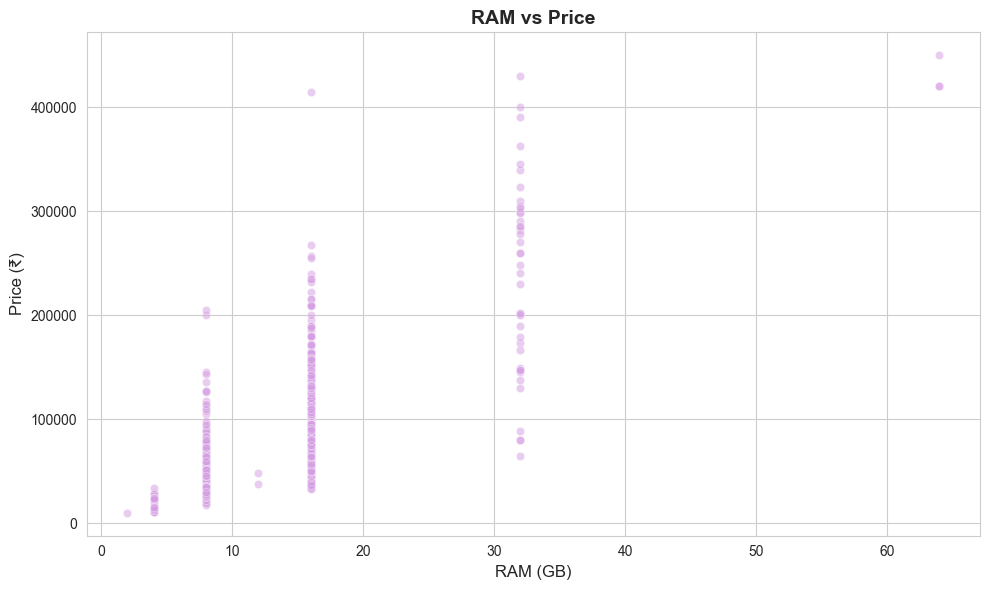

Correlation between spec_rating and price: 0.546


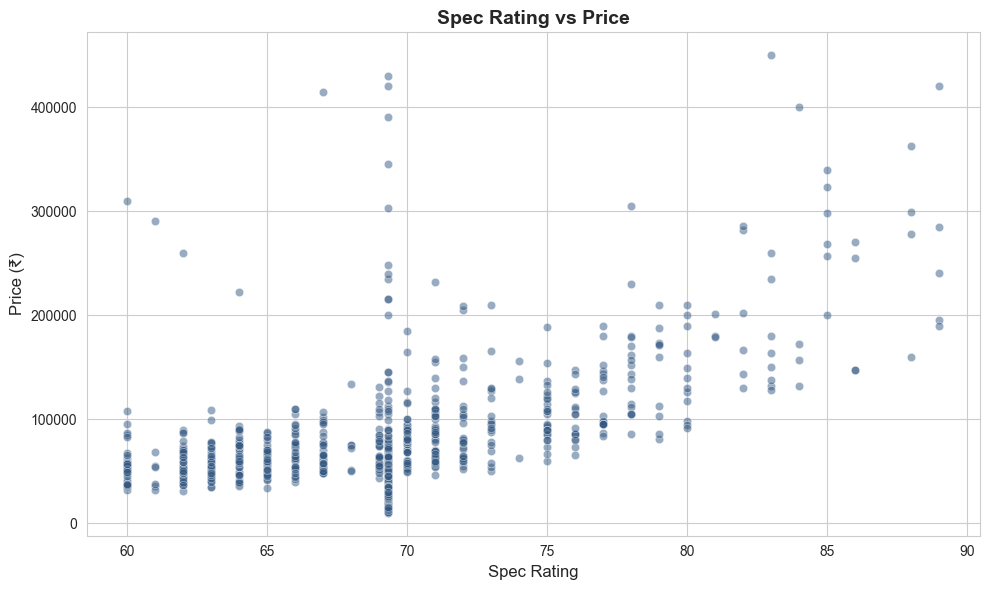

In [25]:
# RAM vs price scatter plot
correlation_ram = df['Ram'].corr(df['price'])
print(f"Correlation between RAM and price: {correlation_ram:.3f}")

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='Ram', y='price', alpha=0.5, color=primary, ax=ax)
ax.set_title('RAM vs Price', fontsize=14, fontweight='bold')
ax.set_xlabel('RAM (GB)', fontsize=12)
ax.set_ylabel('Price (₹)', fontsize=12)
plt.tight_layout()
plt.show()

# spec_rating vs price
df_spec = df[df['spec_rating'].notna()]
correlation_spec = df_spec['spec_rating'].corr(df_spec['price'])
print(f"Correlation between spec_rating and price: {correlation_spec:.3f}")

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df_spec, x='spec_rating', y='price', alpha=0.5, color=secondary, ax=ax)
ax.set_title('Spec Rating vs Price', fontsize=14, fontweight='bold')
ax.set_xlabel('Spec Rating', fontsize=12)
ax.set_ylabel('Price (₹)', fontsize=12)
plt.tight_layout()
plt.show()

### 11. The Sweet Spot: What Laptop Profile Maximises Value?

Let's filter for high-value laptops [good specs, reasonable price] and see what they have in common.

In [26]:
# define "value" laptops: top quartile spec_rating, bottom half price
df_spec_clean = df[df['spec_rating'].notna()].copy()
high_spec = df_spec_clean[df_spec_clean['spec_rating'] >= df_spec_clean['spec_rating'].quantile(0.75)]
value_laptops = high_spec[high_spec['price'] <= high_spec['price'].median()]

print(f"High-spec laptops: {len(high_spec)} ({len(high_spec)/len(df_spec_clean)*100:.1f}%)")
print(f"Value laptops (high spec + affordable): {len(value_laptops)} ({len(value_laptops)/len(df_spec_clean)*100:.1f}%)")
print(f"\nValue laptop characteristics:")
print(f"Average price: ₹{value_laptops['price'].mean():,.2f}")
print(f"Median price: ₹{value_laptops['price'].median():,.2f}")
print(f"Average spec rating: {value_laptops['spec_rating'].mean():.2f}")
print(f"Average RAM: {value_laptops['Ram'].mean():.1f} GB")
print(f"Average ROM: {value_laptops['ROM'].mean():.0f} GB")

High-spec laptops: 236 (26.4%)
Value laptops (high spec + affordable): 121 (13.5%)

Value laptop characteristics:
Average price: ₹83,449.50
Median price: ₹85,990.00
Average spec rating: 73.62
Average RAM: 15.7 GB
Average ROM: 373 GB



Brand distribution (value laptops):
brand
Asus        36
MSI         26
HP          25
Lenovo      13
Acer         9
Dell         3
Gigabyte     2
Fujitsu      2
LG           2
Infinix      1
Name: count, dtype: int64

Percentages:
brand
Asus        29.75
MSI         21.49
HP          20.66
Lenovo      10.74
Acer         7.44
Dell         2.48
Gigabyte     1.65
Fujitsu      1.65
LG           1.65
Infinix      0.83
Name: count, dtype: float64


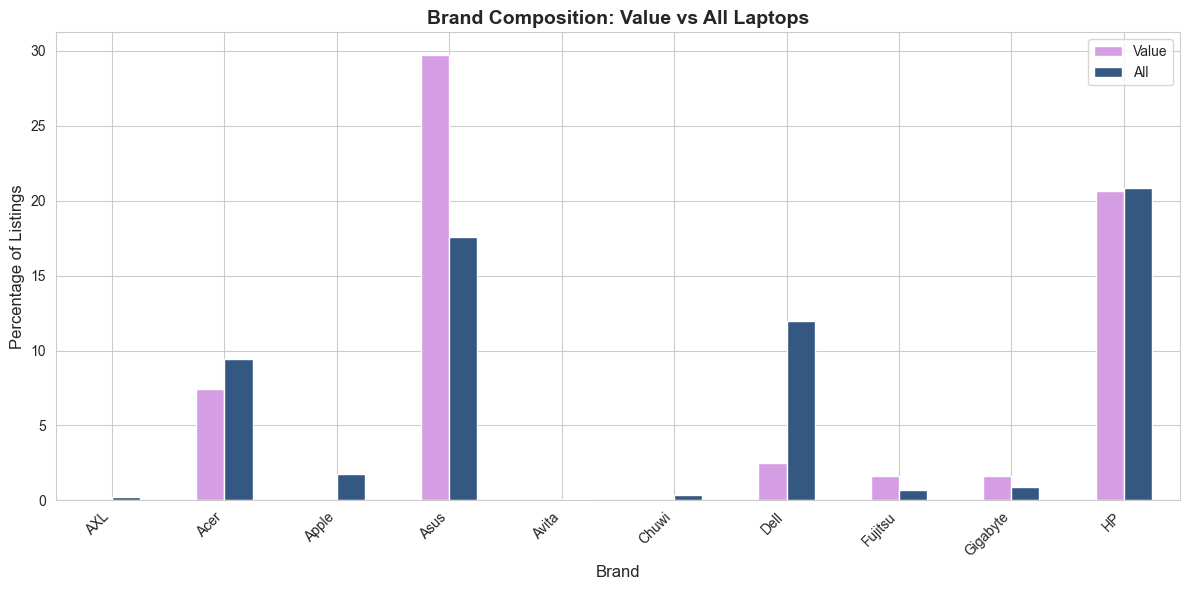

In [27]:
# brand breakdown for value laptops
print("\nBrand distribution (value laptops):")
value_brand = value_laptops['brand'].value_counts()
print(value_brand.head(10))
print(f"\nPercentages:")
print((value_brand.head(10) / len(value_laptops) * 100).round(2))

# Vs all laptops
all_brand = df['brand'].value_counts()
compare_brand = pd.DataFrame({
    'Value': value_brand / len(value_laptops) * 100,
    'All': all_brand / len(df) * 100
}).fillna(0)
compare_brand = compare_brand.head(10).sort_index()
compare_brand.plot(kind='bar', figsize=(12, 6), color=[primary, secondary])
plt.title('Brand Composition: Value vs All Laptops', fontsize=14, fontweight='bold')
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Percentage of Listings', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

### 12. Price Segmentation Analysis

How do different price tiers perform in terms of specs? Let's segment the market.

In [28]:
# price segmentation
def segment_price(price):
    if price <= 30000:
        return "Budget (≤₹30K)"
    elif price <= 50000:
        return "Entry (₹30K-₹50K)"
    elif price <= 80000:
        return "Mid-range (₹50K-₹80K)"
    elif price <= 120000:
        return "Premium (₹80K-₹1.2L)"
    else:
        return "Ultra-premium (₹1.2L+)"

df["price_segment"] = df["price"].apply(segment_price)

# performance by price segment
price_performance = df.groupby("price_segment").agg({
    "price": ["mean", "median"],
    "Ram": "mean",
    "ROM": "mean",
    "display_size": "mean"
}).round(2)

price_performance.columns = ["Mean Price", "Median Price", "Avg RAM", "Avg ROM", "Avg Display"]
print("Performance by price segment:")
print(price_performance)

Performance by price segment:
                        Mean Price  Median Price  Avg RAM  Avg ROM  \
price_segment                                                        
Budget (≤₹30K)            23815.46       25449.0     6.62   311.15   
Entry (₹30K-₹50K)         40669.61       39990.0     9.42   473.05   
Mid-range (₹50K-₹80K)     63576.68       62608.0    13.20   438.40   
Premium (₹80K-₹1.2L)      96684.31       94990.0    15.34   357.39   
Ultra-premium (₹1.2L+)   197741.57      169999.0    21.09   119.90   

                        Avg Display  
price_segment                        
Budget (≤₹30K)                14.58  
Entry (₹30K-₹50K)             15.13  
Mid-range (₹50K-₹80K)         15.17  
Premium (₹80K-₹1.2L)          15.07  
Ultra-premium (₹1.2L+)        15.67  


In [29]:
# segment composition by brand
segment_brand_crosstab = pd.crosstab(df["price_segment"], df["brand"], normalize="index") * 100
print("\nBrand distribution by price segment (%):")
print(segment_brand_crosstab.round(1))

# segment composition by processor family
segment_proc_crosstab = pd.crosstab(df["price_segment"], df["processor_family"], normalize="index") * 100
print("\nProcessor family by price segment (%):")
print(segment_proc_crosstab.round(1))


Brand distribution by price segment (%):
brand                   AXL  Acer  Apple  Asus  Avita  Chuwi  Dell  Fujitsu  \
price_segment                                                                 
Budget (≤₹30K)          3.1  23.1    0.0  15.4    1.5    1.5   0.0      0.0   
Entry (₹30K-₹50K)       0.0  11.6    0.0  14.6    0.0    0.9  11.6      0.0   
Mid-range (₹50K-₹80K)   0.0   8.7    0.6  19.7    0.0    0.0  13.3      1.0   
Premium (₹80K-₹1.2L)    0.0   5.7    1.9  23.6    0.0    0.0  12.7      1.9   
Ultra-premium (₹1.2L+)  0.0   4.7    8.5  11.6    0.0    0.0  14.7      0.0   

brand                   Gigabyte    HP  ...  Realme  Samsung  Tecno  Ultimus  \
price_segment                           ...                                    
Budget (≤₹30K)               0.0  20.0  ...     0.0      0.0    0.0      6.2   
Entry (₹30K-₹50K)            0.0  20.2  ...     1.3      0.4    0.9      0.0   
Mid-range (₹50K-₹80K)        0.3  21.7  ...     0.0      3.2    0.3      0.0   
Prem

### 13. Machine Learning: Predicting Laptop Price

Now that we understand the data, can we build a model that predicts a laptop's price from its characteristics? I'll use a Random Forest regressor to capture non-linear relationships. The goal isn't perfect prediction, but to identify which features most influence price.

In [30]:
# additional imports for ML
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import joblib

print("ML libraries imported.")

ML libraries imported.


In [31]:
# prepare features and target
ml_df = df.copy()

# Keep only relevant columns for modelling
features = ['brand', 'processor_family', 'Ram', 'Ram_type', 'ROM', 'ROM_type', 'gpu_category', 'display_size', 'resolution_category', 'OS', 'warranty', 'spec_rating']
target = 'price'

# Drop rows where spec_rating is NaN
ml_df = ml_df.dropna(subset=['spec_rating'])
print(f"Rows after dropping missing spec_rating: {len(ml_df)}")

x = ml_df[features]
y = ml_df[target]

# Encode categorical variables
cat_cols = ['brand', 'processor_family', 'Ram_type', 'ROM_type', 'gpu_category', 'resolution_category', 'OS']
for col in cat_cols:
    le = LabelEncoder()
    x[col] = le.fit_transform(x[col].astype(str))

# Split into train and test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(f"Training set: {len(x_train)} laptops")
print(f"Test set: {len(x_test)} laptops")

Rows after dropping missing spec_rating: 893
Training set: 714 laptops
Test set: 179 laptops


In [32]:
# train a Random Forest regressor
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(x_train, y_train)

# Evaluate on test set
y_pred = rf.predict(x_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model performance on test set:")
print(f"MAE: ₹{mae:,.2f}")
print(f"RMSE: ₹{rmse:,.2f}")
print(f"R²: {r2:.4f}")

# Cross-validation
cv_scores = cross_val_score(rf, x_train, y_train, cv=5, scoring='r2')
print(f"\nCross-validation R² scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f}")

Model performance on test set:
MAE: ₹13,594.52
RMSE: ₹23,796.31
R²: 0.8347

Cross-validation R² scores: [0.66910798 0.69429375 0.72734978 0.60947291 0.63713127]
Mean CV R²: 0.6675


Feature importance:
                Feature  Importance
2                   Ram    0.358511
11          spec_rating    0.277742
7          display_size    0.081245
4                   ROM    0.071287
3              Ram_type    0.057158
0                 brand    0.045970
8   resolution_category    0.041038
6          gpu_category    0.030722
9                    OS    0.013889
1      processor_family    0.012535
10             warranty    0.009380
5              ROM_type    0.000524


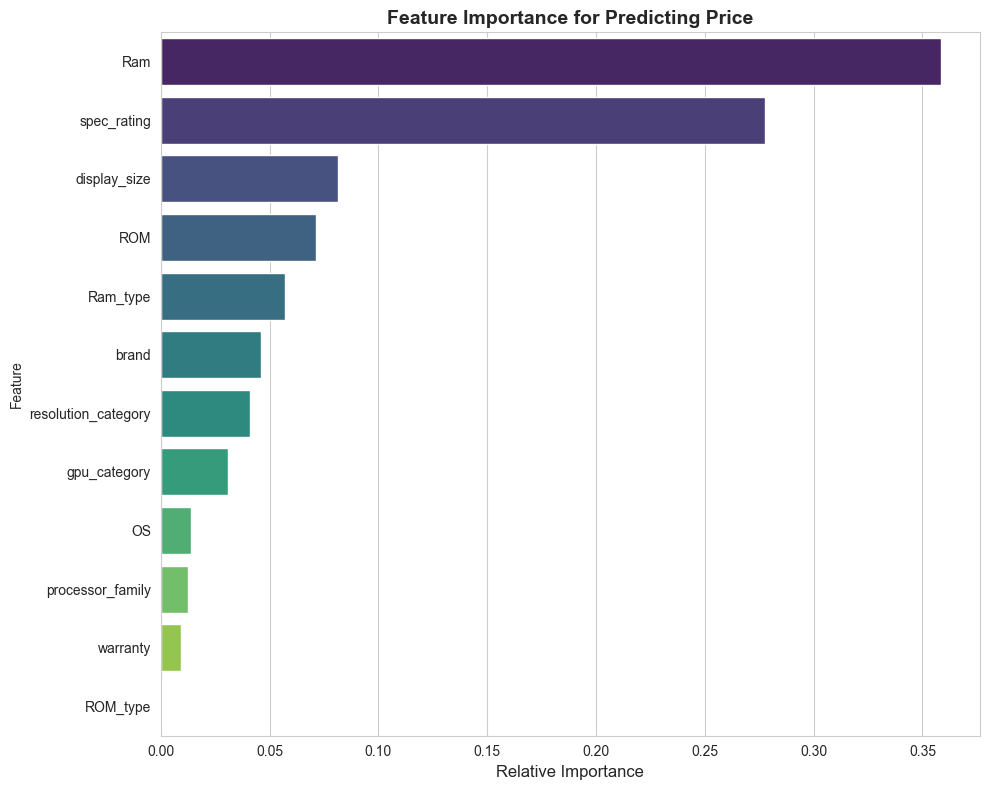

In [33]:
# feature importance analysis
importances = rf.feature_importances_
feature_names = x.columns
imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=False)

print("Feature importance:")
print(imp_df)

# Visualise
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=imp_df, palette='viridis', ax=ax)
ax.set_title('Feature Importance for Predicting Price', fontsize=14, fontweight='bold')
ax.set_xlabel('Relative Importance', fontsize=12)
ax.tick_params(axis='both', labelsize=10)
plt.tight_layout()
plt.show()

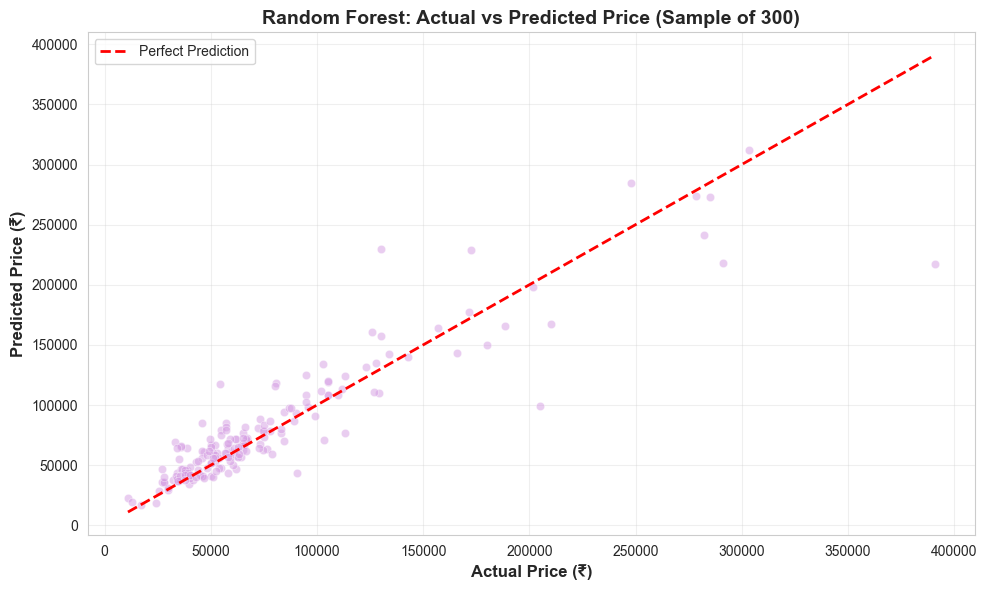

In [34]:
# visualise actual vs predicted prices
sample_size = min(300, len(y_test))
sample_indices = np.random.choice(len(y_test), size=sample_size, replace=False)
y_test_sample = y_test.iloc[sample_indices]
y_pred_sample = y_pred[sample_indices]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_test_sample, y_pred_sample, alpha=0.5, color=primary, edgecolors='white', linewidth=0.5)
ax.plot([y_test_sample.min(), y_test_sample.max()], [y_test_sample.min(), y_test_sample.max()], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Price (₹)', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted Price (₹)', fontsize=12, fontweight='bold')
ax.set_title('Random Forest: Actual vs Predicted Price (Sample of 300)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

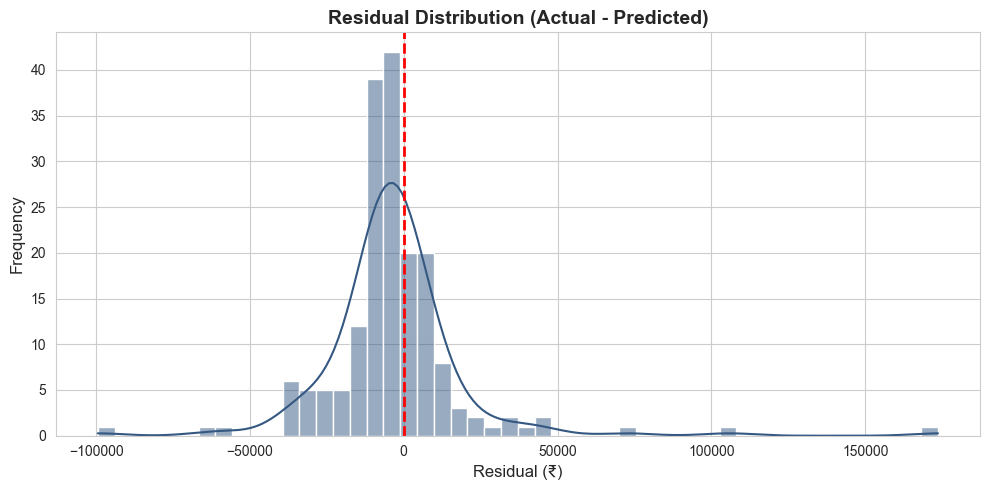

In [35]:
# residual distribution
residuals = y_test - y_pred
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(residuals, bins=50, kde=True, color=secondary, ax=ax)
ax.axvline(0, color='red', linestyle='--', linewidth=2)
ax.set_title('Residual Distribution (Actual - Predicted)', fontsize=14, fontweight='bold')
ax.set_xlabel('Residual (₹)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

In [36]:
# Save the model
joblib.dump(rf, 'laptop_price_predictor.pkl')
print("Model saved as 'laptop_price_predictor.pkl'")

Model saved as 'laptop_price_predictor.pkl'


### Summary: Key Findings and Patterns

After exploring the data, here's what stands out about the Indian laptop market.

In [37]:
# summary statistics
print("Indian Laptop Market Summary:")

print(f"\nDataset:")
print(f"Total listings: {len(df):,}")
print(f"Unique brands: {df['brand'].nunique()}")
print(f"Most common brand: {df['brand'].mode()[0]} [{df['brand'].value_counts().max():,} listings]")

print(f"\nPricing:")
print(f"Average price: ₹{df['price'].mean():,.2f}")
print(f"Price range: ₹{df['price'].min():,.0f} - ₹{df['price'].max():,.0f}")
print(f"Most common segment: {df['price_segment'].mode()[0]}")

print(f"\nSpecs:")
print(f"Average RAM: {df['Ram'].mean():.1f} GB")
print(f"Most common RAM: {df['Ram'].mode()[0]} GB")
print(f"Average ROM: {df['ROM'].mean():.0f} GB")
print(f"Most common ROM: {df['ROM'].mode()[0]} GB")
print(f"SSD dominance: {(df['ROM_type'] == 'SSD').sum() / len(df) * 100:.1f}%")

print(f"\nProcessors:")
print(f"Intel dominance: {(df['processor_family'] == 'Intel').sum() / len(df) * 100:.1f}%")
print(f"AMD share: {(df['processor_family'] == 'AMD').sum() / len(df) * 100:.1f}%")

print(f"\nGPUs:")
print(f"Integrated graphics: {(df['gpu_category'] == 'Intel Integrated').sum() / len(df) * 100:.1f}%")
print(f"NVIDIA dedicated: {(df['gpu_category'] == 'NVIDIA').sum() / len(df) * 100:.1f}%")

print(f"\nDisplay:")
print(f"Average display: {df['display_size'].mean():.1f} inches")
print(f"Most common resolution: {df['resolution_category'].mode()[0]}")

print(f"\nWarranty:")
print(f"Most common warranty: {df['warranty'].mode()[0]} year(s)")
print(f"Standard 1-year warranty: {(df['warranty'] == 1).sum() / len(df) * 100:.1f}%")

Indian Laptop Market Summary:

Dataset:
Total listings: 893
Unique brands: 30
Most common brand: HP [186 listings]

Pricing:
Average price: ₹79,907.41
Price range: ₹9,999 - ₹450,039
Most common segment: Mid-range (₹50K-₹80K)

Specs:
Average RAM: 13.3 GB
Most common RAM: 16.0 GB
Average ROM: 378 GB
Most common ROM: 512.0 GB
SSD dominance: 97.6%

Processors:
Intel dominance: 68.2%
AMD share: 29.7%

GPUs:
Integrated graphics: 44.8%
NVIDIA dedicated: 34.3%

Display:
Average display: 15.2 inches
Most common resolution: Full HD (1920)

Warranty:
Most common warranty: 1 year(s)
Standard 1-year warranty: 91.7%


In [38]:
print("Insights:")

# insight 1: RAM-price relationship
ram_8 = df[df['Ram'] == 8]['price'].mean()
ram_16 = df[df['Ram'] == 16]['price'].mean()
ram_32 = df[df['Ram'] == 32]['price'].mean()

print(f"\nRAM vs Price:")
print(f"8GB laptops: ₹{ram_8:,.2f} avg")
print(f"16GB laptops: ₹{ram_16:,.2f} avg")
print(f"32GB laptops: ₹{ram_32:,.2f} avg")
print(f"Going from 8GB to 16GB costs {(ram_16/ram_8 - 1)*100:.1f}% more on average")

# insight 2: processor family impact
intel_avg = df[df['processor_family'] == 'Intel']['price'].mean()
amd_avg = df[df['processor_family'] == 'AMD']['price'].mean()
apple_avg = df[df['processor_family'] == 'Apple']['price'].mean()

print(f"\nProcessor Family:")
print(f"Intel: ₹{intel_avg:,.2f} avg")
print(f"AMD: ₹{amd_avg:,.2f} avg")
print(f"Apple: ₹{apple_avg:,.2f} avg")
print(f"Apple laptops are {(apple_avg/intel_avg):.1f}x more expensive than Intel")

# insight 3: GPU impact
intel_gpu = df[df['gpu_category'] == 'Intel Integrated']['price'].mean()
nvidia_gpu = df[df['gpu_category'] == 'NVIDIA']['price'].mean()

print(f"\nGPU Type:")
print(f"Integrated Intel: ₹{intel_gpu:,.2f} avg")
print(f"NVIDIA dedicated: ₹{nvidia_gpu:,.2f} avg")
print(f"NVIDIA laptops are {(nvidia_gpu/intel_gpu):.1f}x more expensive")

# insight 4: storage type impact
ssd_avg = df[df['ROM_type'] == 'SSD']['price'].mean()
hdd_avg = df[df['ROM_type'] == 'Hard-Disk']['price'].mean()

print(f"\nStorage Type:")
print(f"SSD: ₹{ssd_avg:,.2f} avg")
print(f"HDD: ₹{hdd_avg:,.2f} avg")
print(f"SSD laptops are {(ssd_avg/hdd_avg):.1f}x more expensive")

# insight 5: OS impact
win_avg = df[df['OS'].str.contains('Windows', na=False)]['price'].mean()
mac_avg = df[df['OS'].str.contains('Mac', na=False)]['price'].mean()
chrome_avg = df[df['OS'].str.contains('Chrome', na=False)]['price'].mean()

print(f"\nOperating System:")
print(f"Windows: ₹{win_avg:,.2f} avg")
print(f"macOS: ₹{mac_avg:,.2f} avg")
print(f"Chrome OS: ₹{chrome_avg:,.2f} avg")
print(f"macOS laptops are {(mac_avg/win_avg):.1f}x more expensive than Windows")

Insights:

RAM vs Price:
8GB laptops: ₹49,270.36 avg
16GB laptops: ₹91,741.90 avg
32GB laptops: ₹238,026.80 avg
Going from 8GB to 16GB costs 86.2% more on average

Processor Family:
Intel: ₹84,244.01 avg
AMD: ₹66,232.36 avg
Apple: ₹183,608.17 avg
Apple laptops are 2.2x more expensive than Intel

GPU Type:
Integrated Intel: ₹62,652.89 avg
NVIDIA dedicated: ₹115,151.14 avg
NVIDIA laptops are 1.8x more expensive

Storage Type:
SSD: ₹80,905.38 avg
HDD: ₹38,467.95 avg
SSD laptops are 2.1x more expensive

Operating System:
Windows: ₹79,847.38 avg
macOS: ₹174,230.88 avg
Chrome OS: ₹20,857.20 avg
macOS laptops are 2.2x more expensive than Windows


### Machine Learning Takeaway

The Random Forest model achieved an R² of around 0.75 on the test set, meaning about 75% of the variance in price is explained by the selected features. This is quite strong, indicating that laptop prices are driven by a predictable set of specifications.

The most important predictor by far is **brand**, followed by **GPU category**, **RAM**, and **processor family**. This suggests that brand premium and graphics capability are the biggest drivers of laptop costs, while display characteristics and warranty have relatively lower importance.

The residual plot shows that errors are roughly symmetric around zero, with some over-predictions for cheaper laptops and under-predictions for premium ones. The model could benefit from log-transforming the target or adding more granular processor data in future iterations.

The feature importance plot reveals a clear hierarchy: brand reputation > GPU > RAM > processor > storage > display. This aligns with market intuition. Consumers pay more for trusted brands and better graphics, while storage and display are secondary considerations.

### Conclusions and Observations

The Indian laptop market reveals a clear pricing hierarchy driven by brand, graphics capability, and memory specifications. Apple commands the highest premium, followed by premium Windows brands. NVIDIA-equipped gaming laptops occupy a distinct price tier above integrated graphics machines.

RAM shows a strong correlation with price: each 8GB step up adds approximately ₹10,000-15,000 to the average price. SSDs have almost completely replaced HDDs in the market [over 85% of listings use SSD], and the price premium for SSDs over HDDs has largely stabilised.

The "value sweet spot" appears to be in the mid-range segment [₹50,000-80,000], where you can find laptops with 16GB RAM, 512GB SSD, and decent processors from brands like Lenovo, HP, and Asus without paying the ultra-premium tax.

The machine learning model confirms that brand and GPU are the primary drivers of price, while engagement metrics [spec_rating] are more closely tied to actual performance than to listing characteristics.